In [1]:
#Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [42]:
#Loading the data
Pop_health_data_semi = pd.read_csv("C:/Users/HomePC/Desktop/CSA2025/Group1-Healthcare_Access_Inequality_Predictor/Data/Pop_health_data_semi.csv")
Pop_health_data_semi.head()

,Unnamed: 0,county,pop_total,average_rating,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,no._of_facilities
0,0,Baringo,666763,0.003902,284,16,15,19,204309.0,41
1,1,Bomet,875689,0.012987,157,19,12,71,398032.0,77
2,2,Bungoma,1670570,0.019748,881,67,295,210,1342280.0,129
3,3,Busia,893681,0.012500,523,1,219,83,243454.0,35
4,4,Elgeyo/Marakwet,454480,0.050000,237,23,2,67,108943.0,25


In [44]:
#Getting the sum of the number of all beds that are in county facilities
Pop_health_data_semi['number_of_beds'] = (
    Pop_health_data_semi['number_of_beds'].fillna(0) +
    Pop_health_data_semi['number_of_cots'].fillna(0) +
    Pop_health_data_semi['number_of_inpatient_beds'].fillna(0) +
    Pop_health_data_semi['number_of_maternity_beds'].fillna(0)
)
#Displaying the first five rows in the dataframe
Pop_health_data_semi.head()

,Unnamed: 0,county,pop_total,average_rating,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,no._of_facilities
0,0,Baringo,666763,0.003902,334,16,15,19,204309.0,41
1,1,Bomet,875689,0.012987,259,19,12,71,398032.0,77
2,2,Bungoma,1670570,0.019748,1453,67,295,210,1342280.0,129
3,3,Busia,893681,0.012500,826,1,219,83,243454.0,35
4,4,Elgeyo/Marakwet,454480,0.050000,329,23,2,67,108943.0,25


In [45]:
#Dropping the unwanted columns
Pop_health_data_semi.drop(columns=['average_rating','Unnamed: 0','number_of_cots','number_of_inpatient_beds','number_of_maternity_beds'], inplace = True)
Pop_health_data_semi.head()

,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities
0,Baringo,666763,334,204309.0,41
1,Bomet,875689,259,398032.0,77
2,Bungoma,1670570,1453,1342280.0,129
3,Busia,893681,826,243454.0,35
4,Elgeyo/Marakwet,454480,329,108943.0,25


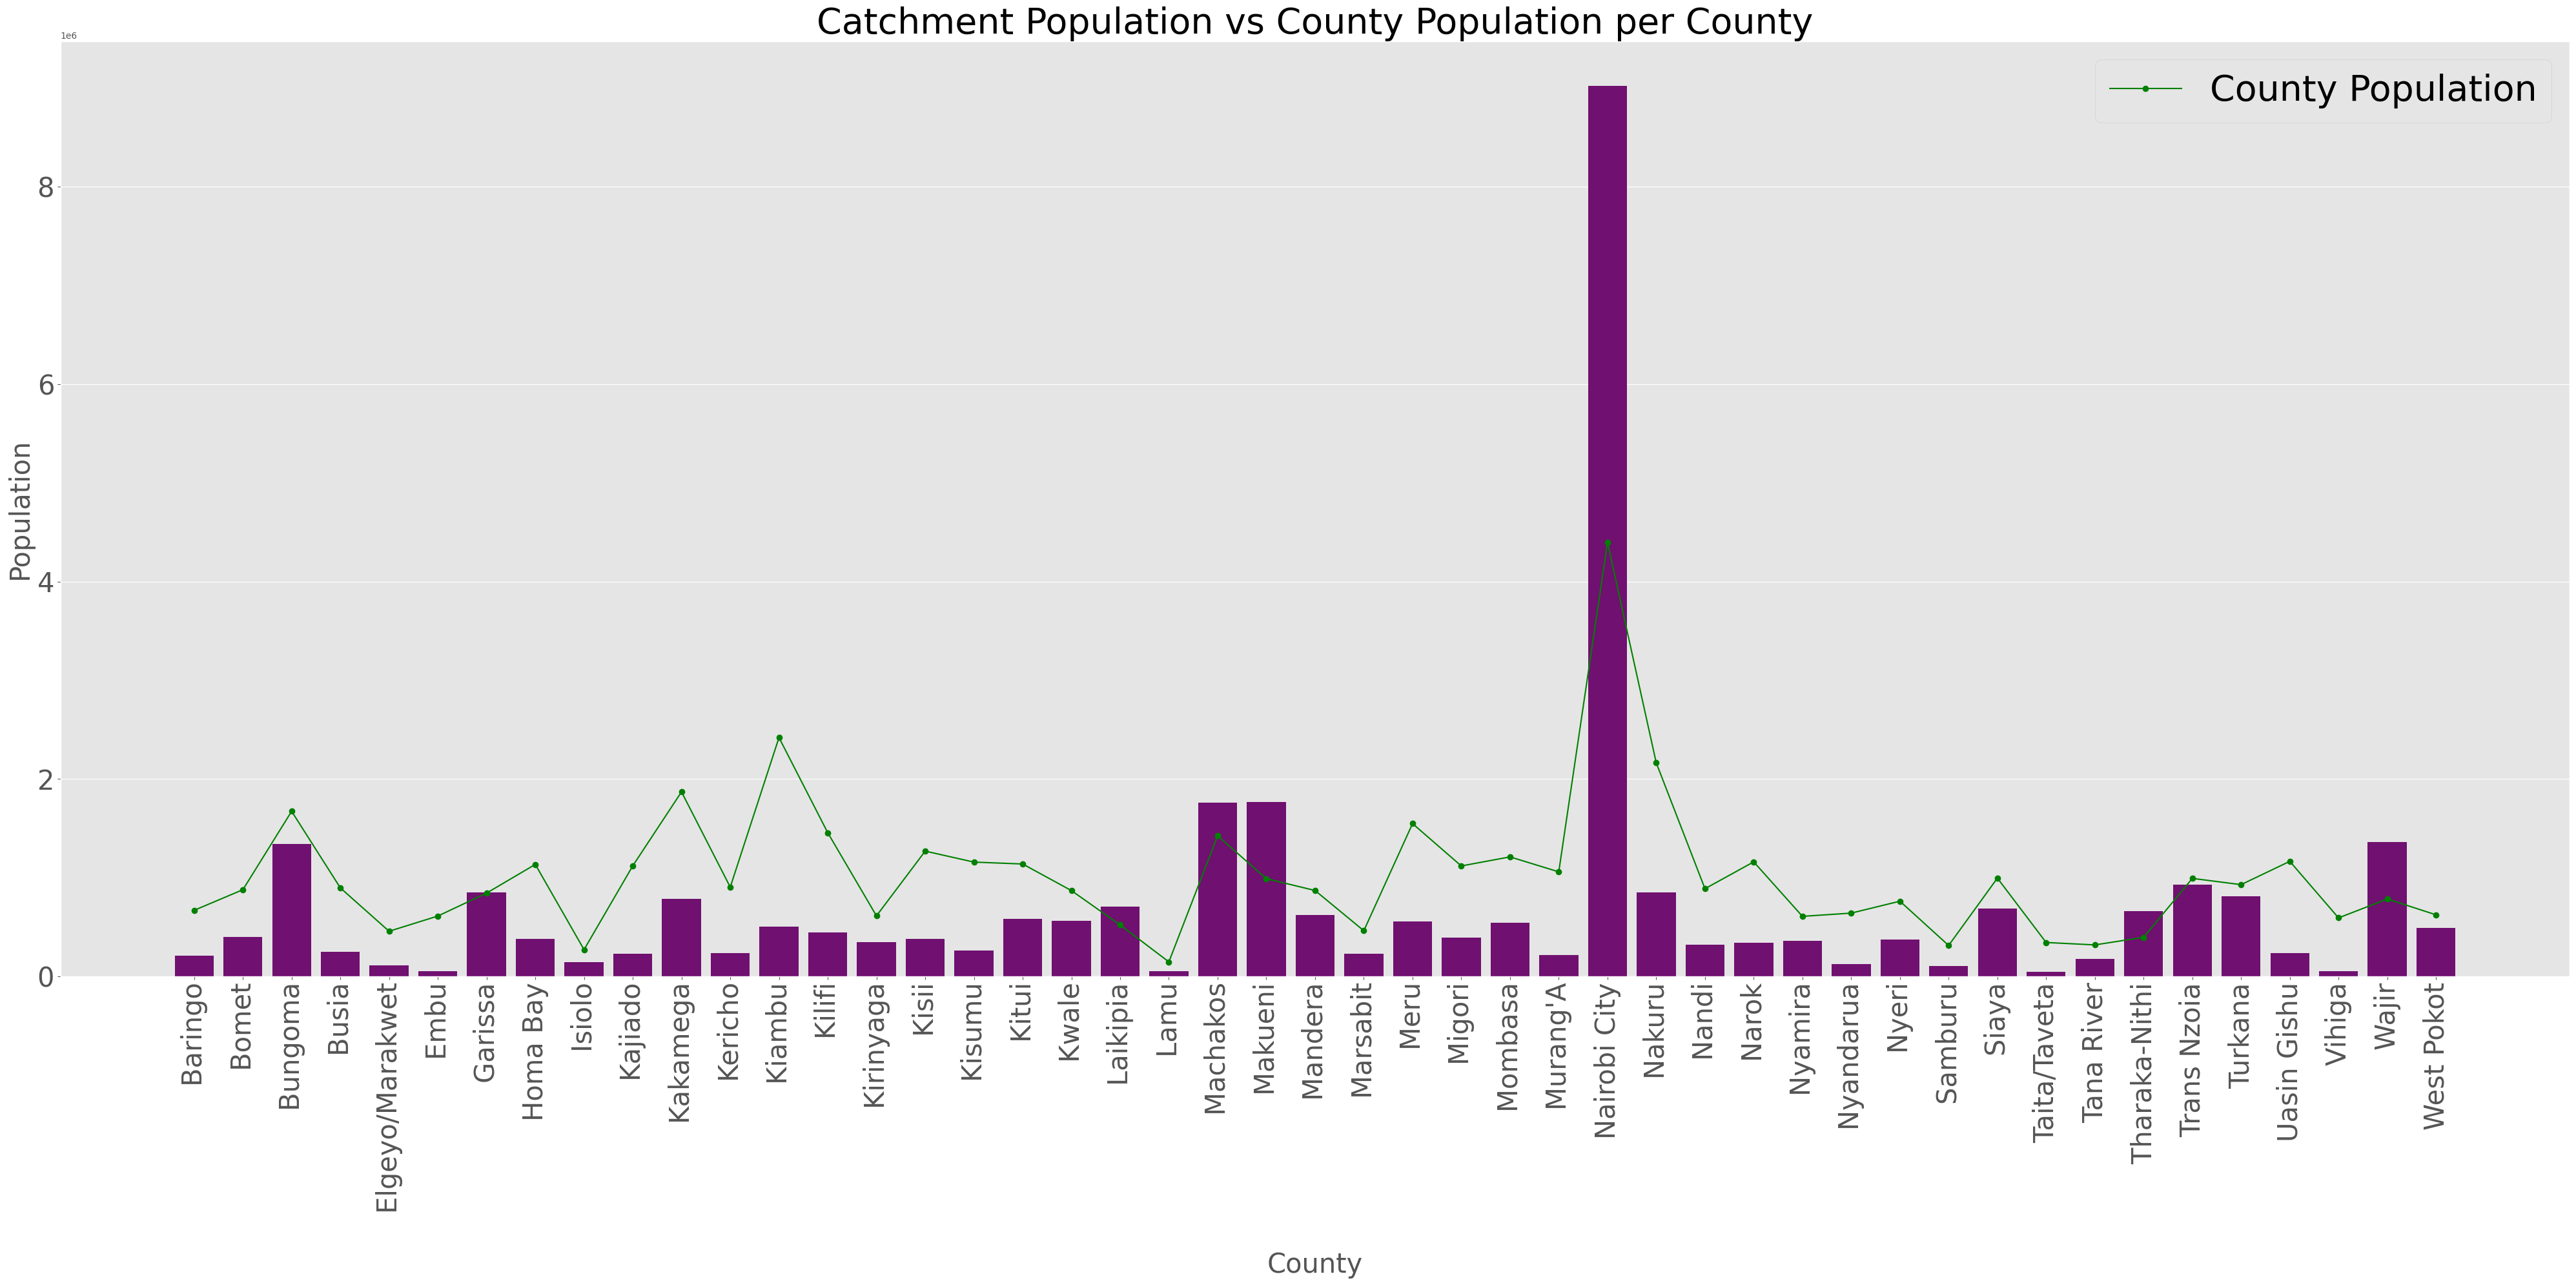

In [46]:
plt.style.use("ggplot")

fig,axes=plt.subplots(figsize=(40,20))

# # Bar plot: facility catchment population
sns.barplot(x='county', y='facility_catchment_population', data = Pop_health_data, color= 'purple')

# Line plot: county population
counties = Pop_health_data_semi['county']
county_population = Pop_health_data_semi['pop_total']

# Plot line graph on the same axes
axes.plot(counties, county_population, color='green', marker='o',label='County Population')

plt.xticks(rotation=90,fontsize=30)  # or rotation=90 for vertical x axis labels
plt.yticks(fontsize=30)

# Axis labels
axes.set_xlabel("County", fontsize=30)
axes.set_ylabel("Population", fontsize=30)

plt.title("Catchment Population vs County Population per County", fontsize=40)
plt.legend(fontsize=40)

# Adjust layout
plt.tight_layout()
plt.show()

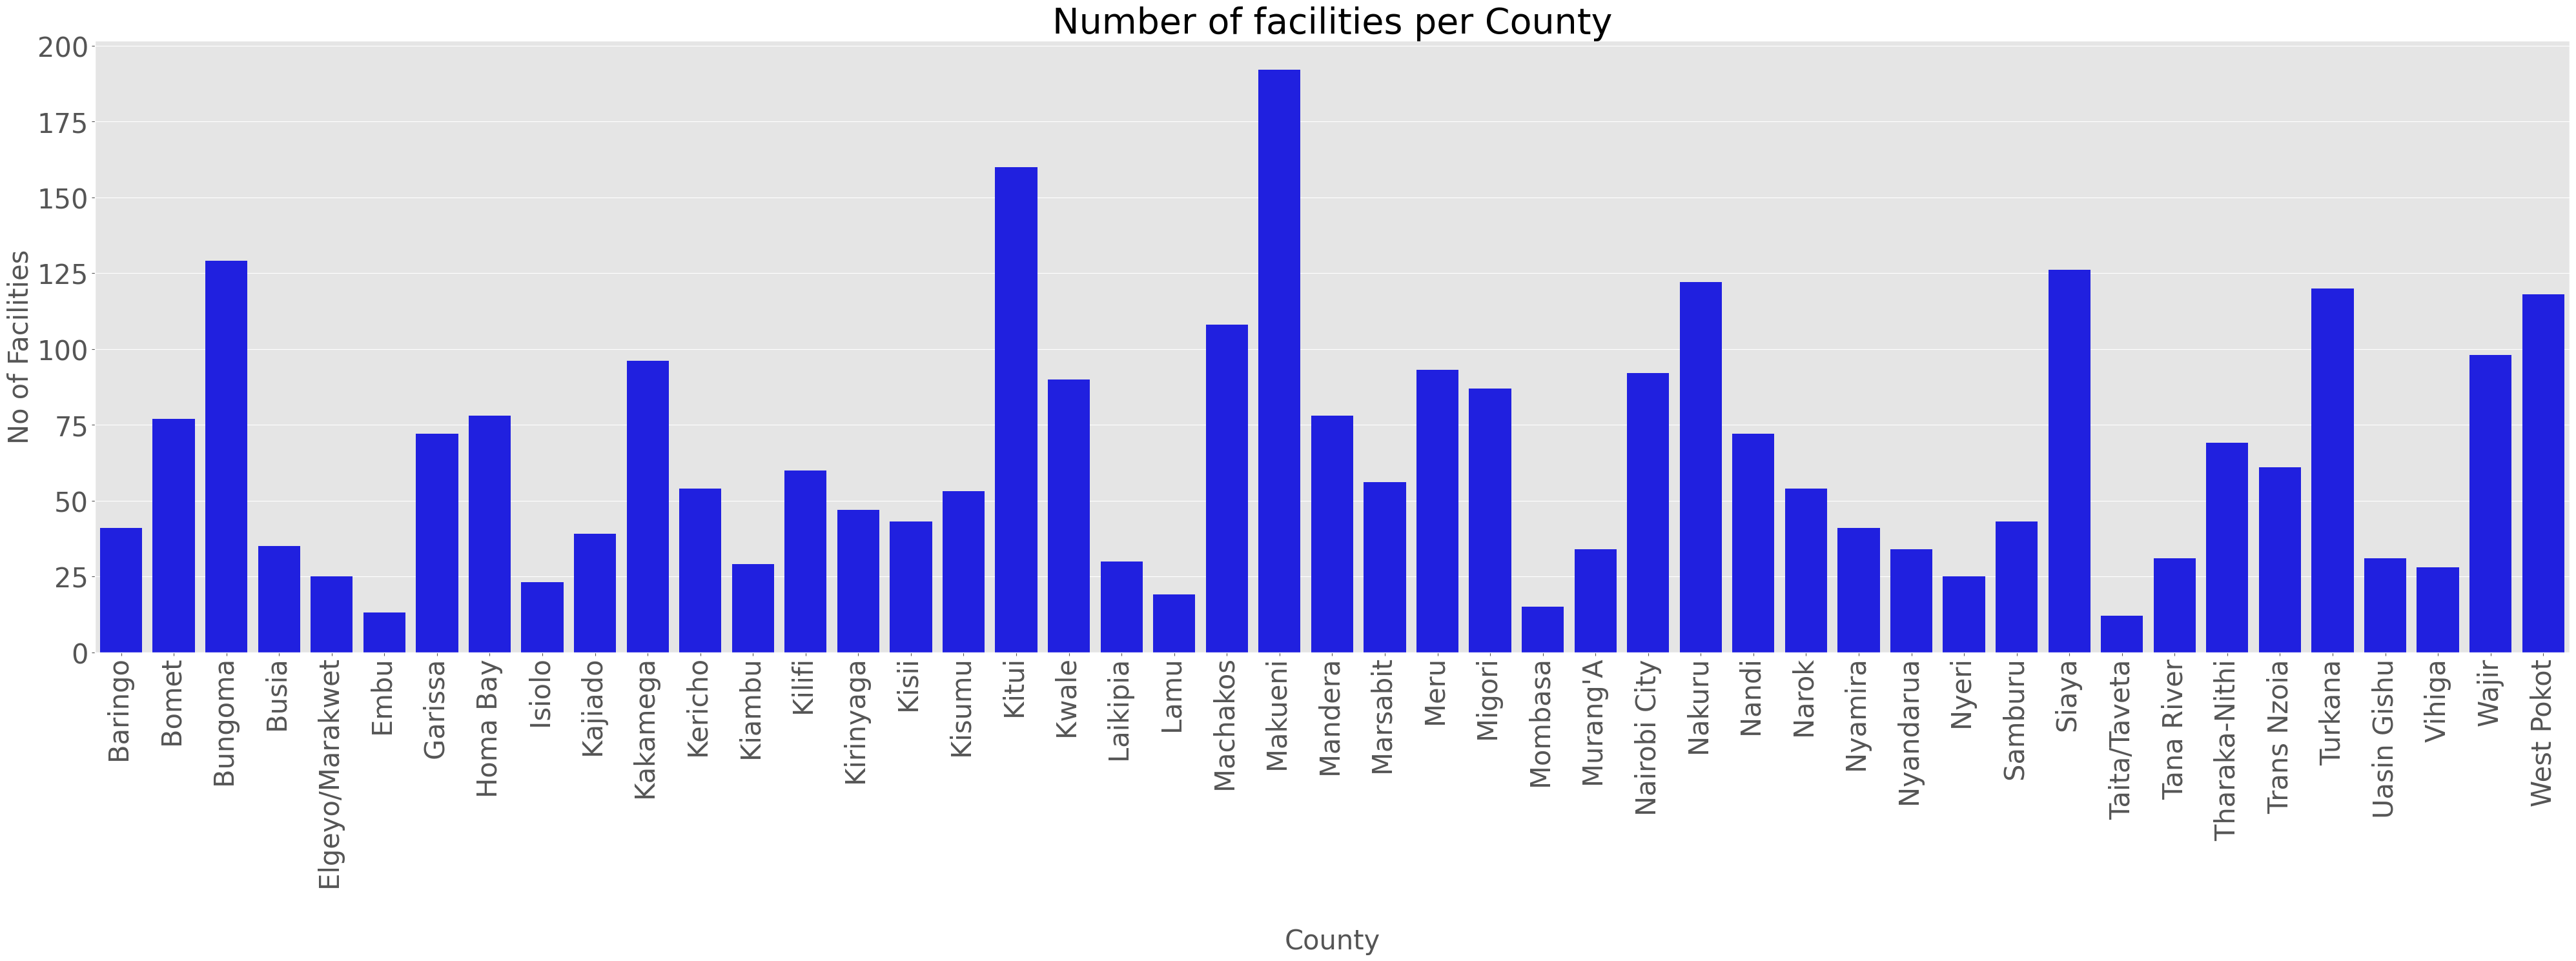

In [47]:
plt.style.use("ggplot")

fig,axes=plt.subplots(figsize=(40,15))

# # Bar plot: facility catchment population
sns.barplot(x='county', y='no._of_facilities', data = Pop_health_data_semi, color= 'blue')

plt.xticks(rotation=90,fontsize=30)  # or rotation=90 for vertical x axis labels
plt.yticks(fontsize=30)

# Axis labels
axes.set_xlabel("County", fontsize=30)
axes.set_ylabel("No of Facilities", fontsize=30)

plt.title("Number of facilities per County", fontsize=40)

# Adjust layout
plt.tight_layout()
plt.show()

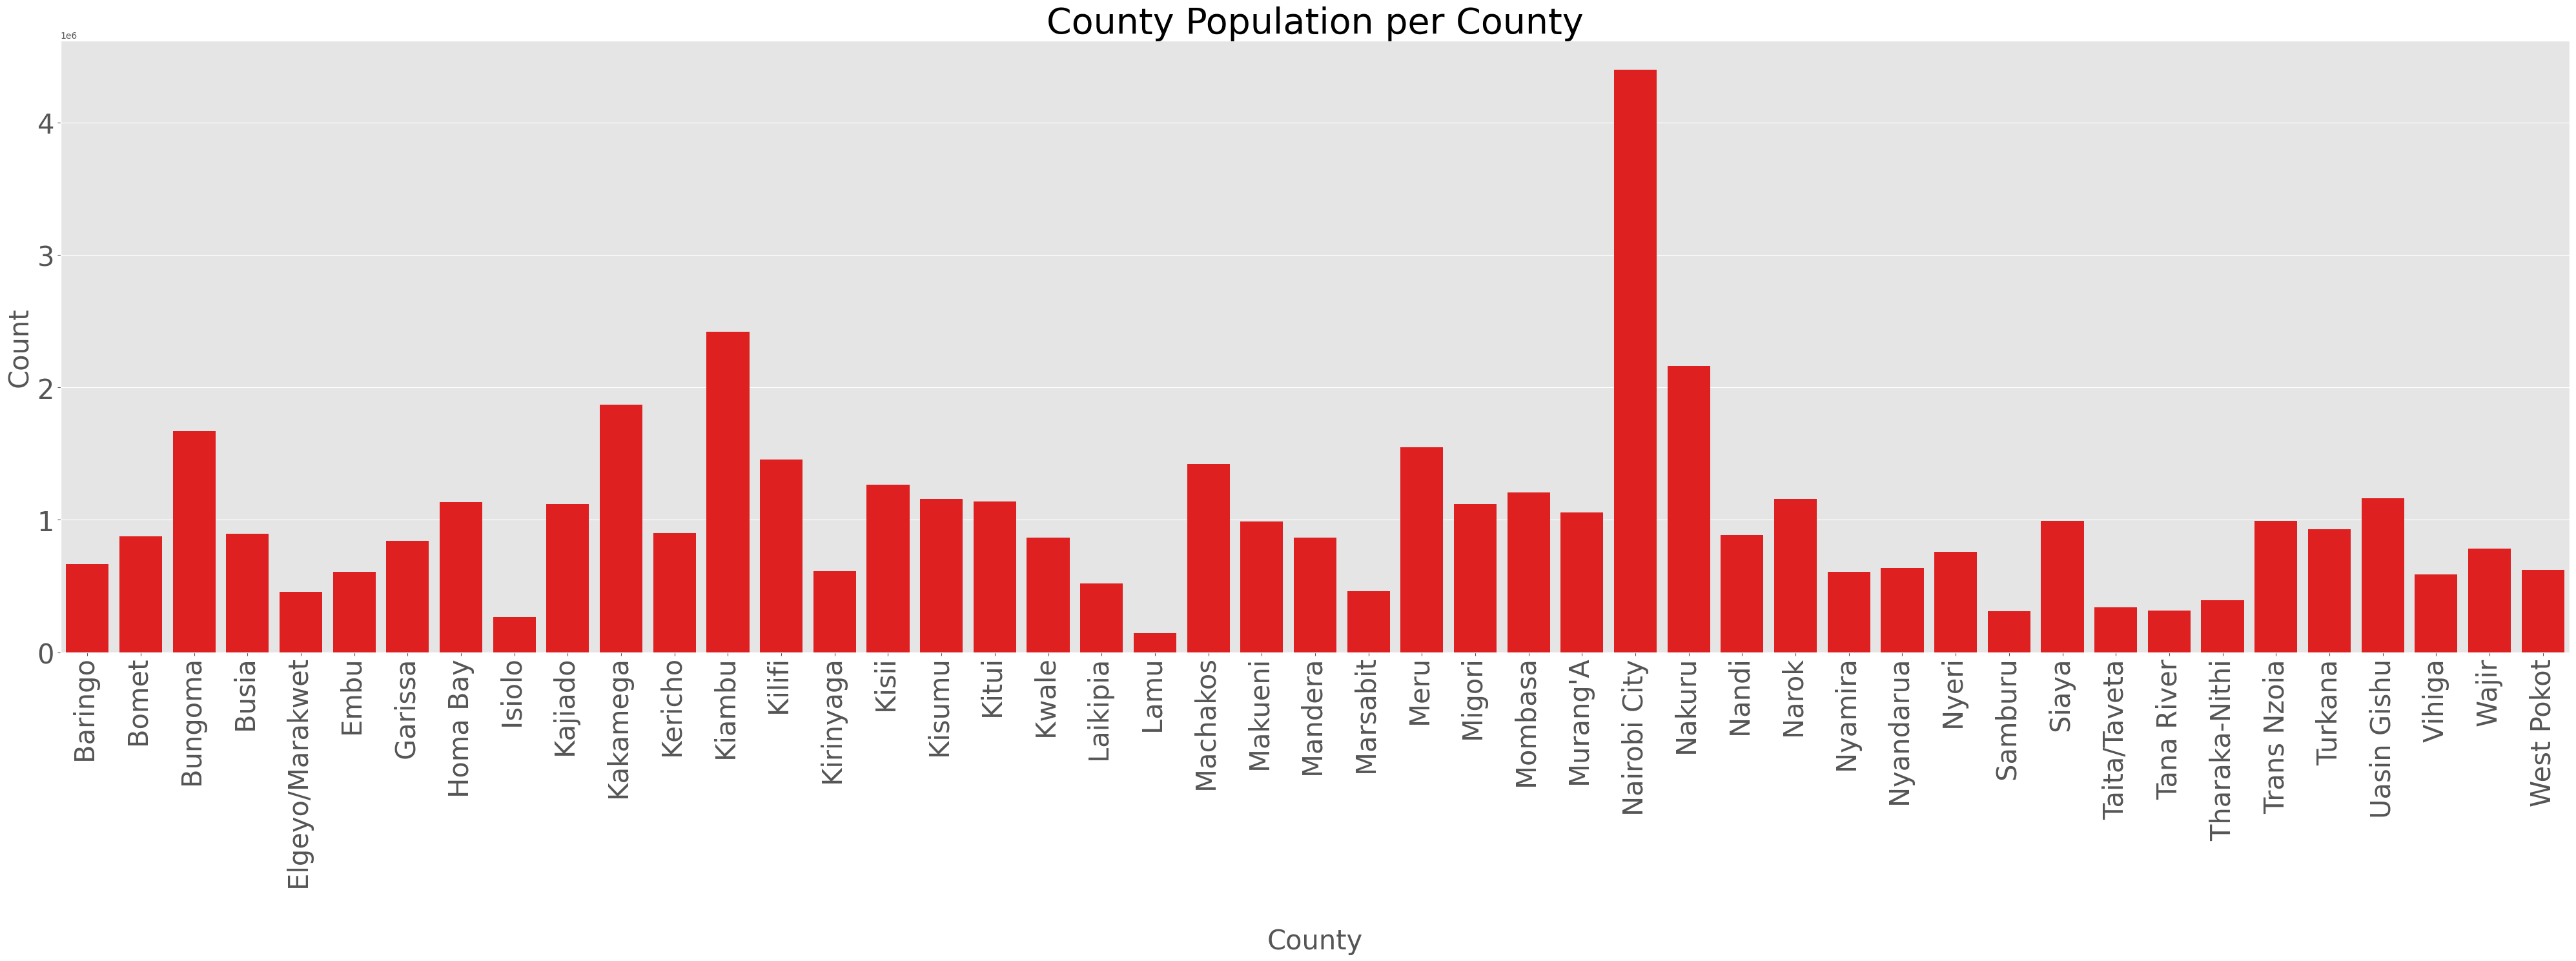

In [48]:
plt.style.use("ggplot")

fig, axes = plt.subplots(figsize=(40,15))

# Bar plot: Number of facilities per county
sns.barplot(x='county', y='pop_total', data = Pop_health_data_semi, color='red', ax=axes,zorder=1)

# Rotate x-axis labels and increase font size
plt.xticks(rotation=90, fontsize=30)
plt.yticks(fontsize=30)

# Title and axis labels
plt.title("County Population per County", fontsize=40)
axes.set_xlabel("County", fontsize=30)
axes.set_ylabel("Count", fontsize=30)

# Layout
plt.tight_layout()
plt.show()


In [50]:
Pop_health_data_semi['access_score'] = Pop_health_data_semi['no._of_facilities'] /Pop_health_data_semi['pop_total']
Pop_health_data_semi.head()

,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities,access_score
0,Baringo,666763,334,204309.0,41,0.000061
1,Bomet,875689,259,398032.0,77,0.000088
2,Bungoma,1670570,1453,1342280.0,129,0.000077
3,Busia,893681,826,243454.0,35,0.000039
4,Elgeyo/Marakwet,454480,329,108943.0,25,0.000055


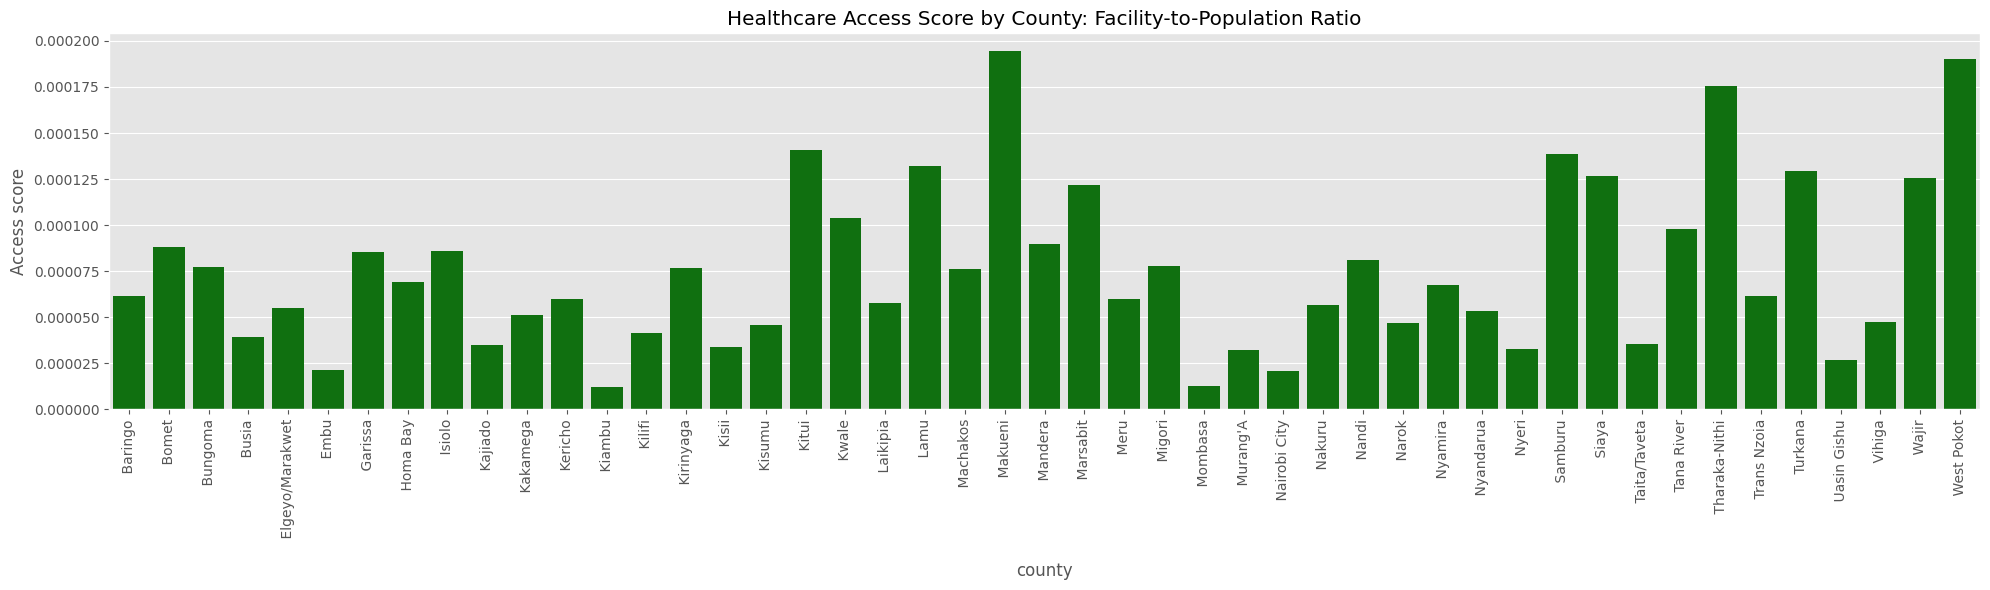

In [51]:
fig,axes=plt.subplots(figsize=(20,6))
sns.barplot(x='county', y='access_score', data = Pop_health_data_semi, color='green')
plt.xticks(rotation=90)  # or rotation=90 for vertical labels
axes.set_ylabel("Access score")
plt.title("Healthcare Access Score by County: Facility-to-Population Ratio")
plt.tight_layout()
plt.show()

In [52]:
Pop_health_data_semi['beds_per_1000'] = (Pop_health_data_semi['number_of_beds'] / Pop_health_data_semi['pop_total']) * 1000
Pop_health_data_semi.head()

,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities,access_score,beds_per_1000
0,Baringo,666763,334,204309.0,41,0.000061,0.500928
1,Bomet,875689,259,398032.0,77,0.000088,0.295767
2,Bungoma,1670570,1453,1342280.0,129,0.000077,0.869763
3,Busia,893681,826,243454.0,35,0.000039,0.924267
4,Elgeyo/Marakwet,454480,329,108943.0,25,0.000055,0.723904


In [53]:
Pop_health_data_semi['access_level'] =Pop_health_data_semi['beds_per_1000'].apply(lambda x: 'Low' if x < 1 else 'High')
Pop_health_data_semi.head()

,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities,access_score,beds_per_1000,access_level
0,Baringo,666763,334,204309.0,41,0.000061,0.500928,Low
1,Bomet,875689,259,398032.0,77,0.000088,0.295767,Low
2,Bungoma,1670570,1453,1342280.0,129,0.000077,0.869763,Low
3,Busia,893681,826,243454.0,35,0.000039,0.924267,Low
4,Elgeyo/Marakwet,454480,329,108943.0,25,0.000055,0.723904,Low


In [54]:
#Shows the mean,std,min,max and percentiles of access score in the dataframe
Pop_health_data_semi['access_score'].describe()

count    47.000000
mean      0.000076
std       0.000045
min       0.000012
25%       0.000044
50%       0.000062
75%       0.000094
max       0.000194
Name: access_score, dtype: float64

In [55]:
#Displays the first five rows of the dataframe
Pop_health_data_semi.head()

,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities,access_score,beds_per_1000,access_level
0,Baringo,666763,334,204309.0,41,0.000061,0.500928,Low
1,Bomet,875689,259,398032.0,77,0.000088,0.295767,Low
2,Bungoma,1670570,1453,1342280.0,129,0.000077,0.869763,Low
3,Busia,893681,826,243454.0,35,0.000039,0.924267,Low
4,Elgeyo/Marakwet,454480,329,108943.0,25,0.000055,0.723904,Low


access_flag
Underserved      23
Low Moderate     12
High Moderate    11
Served            1
Name: count, dtype: int64


C:\Users\HomePC\AppData\Local\Temp\ipykernel_33584\1981583691.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='access_flag', data=Pop_health_data_semi, palette='viridis')


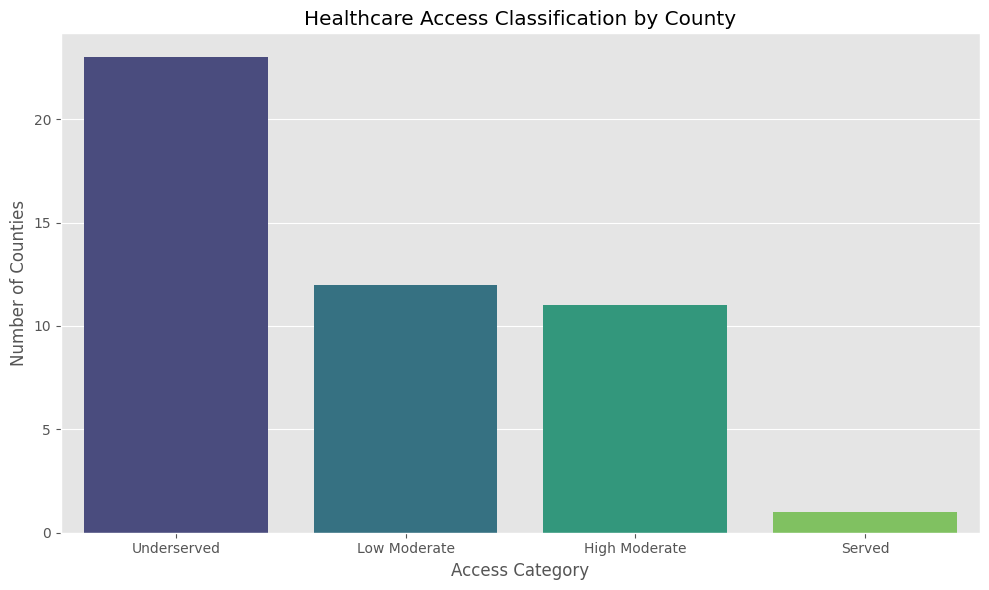

In [56]:
# Calculate percentiles
q1 = Pop_health_data_semi['access_score'].quantile(0.50)
q2 = Pop_health_data_semi['access_score'].quantile(0.75)
q3 = Pop_health_data_semi['access_score'].quantile(1.00)
def categorize_access(score):
    if score < q1:
        return 'Underserved'
    elif score < q2:
        return 'Low Moderate'
    elif score < q3:
        return 'High Moderate'
    else:
        return 'Served'
        
#Categorizes the access flags per access score of a county
Pop_health_data_semi['access_flag'] = Pop_health_data_semi['access_score'].apply(categorize_access)

#Prints the total number of counties that lie in the access flag categories
print(Pop_health_data_semi['access_flag'].value_counts())

#Plots a bar graph showing the access flag distribution in all the counties
plt.figure(figsize=(10,6))
sns.countplot(x='access_flag', data=Pop_health_data_semi, palette='viridis')
plt.title("Healthcare Access Classification by County")
plt.xlabel("Access Category")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()

access_level
Low     36
High    11
Name: count, dtype: int64


C:\Users\HomePC\AppData\Local\Temp\ipykernel_33584\3715395770.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='access_level', data=Pop_health_data_semi, palette='viridis')


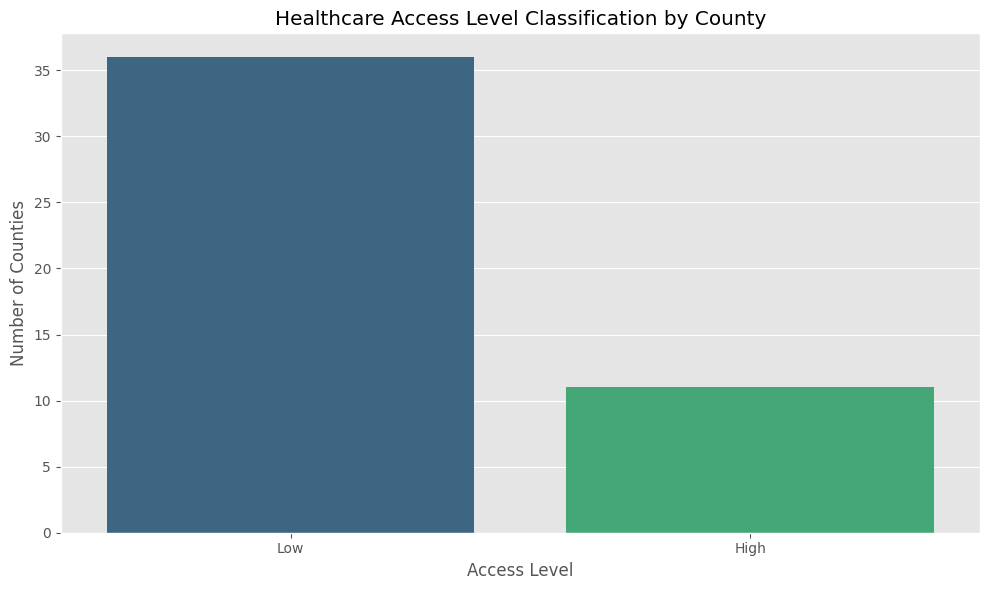

In [57]:
#Prints the total number of the low and high access levels
print(Pop_health_data_semi['access_level'].value_counts())

#Plotting a bar graph of the healthcare access levels
plt.figure(figsize=(10,6))
sns.countplot(x='access_level', data=Pop_health_data_semi, palette='viridis')
plt.title("Healthcare Access Level Classification by County")
plt.xlabel("Access Level")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()


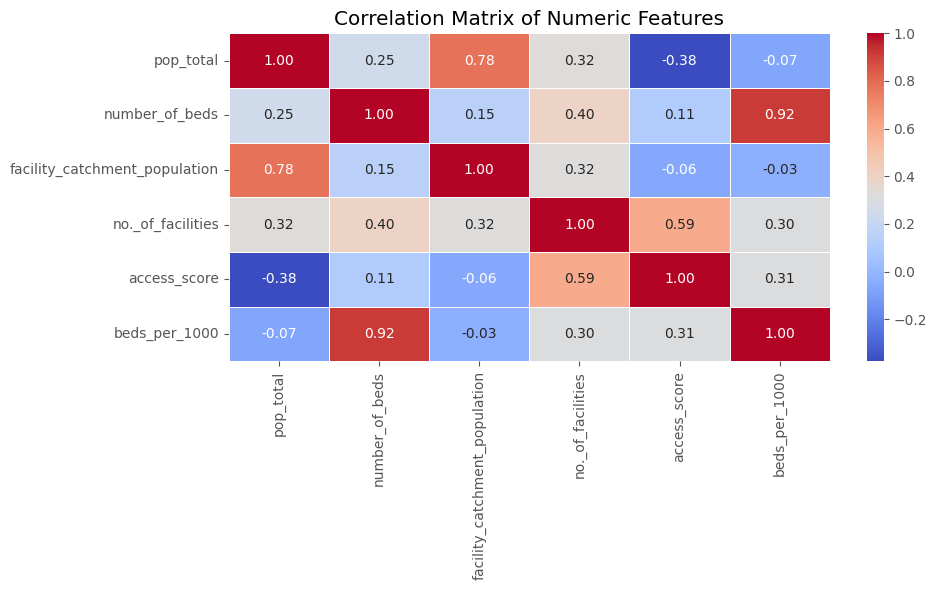

In [58]:
# Create a correlation matrix for the numerical values
num_variables = Pop_health_data_semi.select_dtypes(include='number')

# Create a correlation matrix
corr_matrix = num_variables.corr()

# Make a heatmap out of the corr_matrix
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [59]:
Pop_health_data_final = Pop_health_data_semi
Pop_health_data_final.head()

,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities,access_score,beds_per_1000,access_level,access_flag
0,Baringo,666763,334,204309.0,41,0.000061,0.500928,Low,Underserved
1,Bomet,875689,259,398032.0,77,0.000088,0.295767,Low,Low Moderate
2,Bungoma,1670570,1453,1342280.0,129,0.000077,0.869763,Low,Low Moderate
3,Busia,893681,826,243454.0,35,0.000039,0.924267,Low,Underserved
4,Elgeyo/Marakwet,454480,329,108943.0,25,0.000055,0.723904,Low,Underserved


In [60]:
#Saving the data to csv file
Pop_health_data_final.to_csv("C:/Users/HomePC/Desktop/CSA2025/Group1-Healthcare_Access_Inequality_Predictor/Data/Pop_health_data_final.csv")